## Sales Forecast using Linear Regression
    (Advertising Spend Assignment)
    Requirement: 
    a. Predict product sales based on advertising spend using Linear 
    Regression 
    b. Generate a heat map of Advertising Spend Vs Sales Revenue 
    c. Visualize the data as a scatter plot with a regression line 
    d. Compute Mean Squared Error, Absolute Mean Error & R2 Score  

## Step 1: Import Libraries

In [13]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## Step 2: Import Dataset

In [23]:


# Load dataset

df = pd.read_csv("advertising_spend.csv")

df.columns = ['Advertising_Spend', 'Sales_Revenue']

print(df.head())


   Advertising_Spend  Sales_Revenue
0        2743.579875   10562.775144
1        8798.436865   29248.946706
2        7994.517614   28648.516173
3        6618.673163   22403.006889
4        8520.759118   33363.200297


In [24]:
df.info

<bound method DataFrame.info of      Advertising_Spend  Sales_Revenue
0          2743.579875   10562.775144
1          8798.436865   29248.946706
2          7994.517614   28648.516173
3          6618.673163   22403.006889
4          8520.759118   33363.200297
..                 ...            ...
495        9277.309582   33443.620815
496        5445.575590   15347.161636
497        8436.129614   22926.341094
498        5257.483975   15342.348458
499        6273.498311   21772.060104

[500 rows x 2 columns]>

## Step 3: Data Preprocessing

In [25]:

# check missing values
print(df.isnull().sum())

# features and target
X = df[['Advertising_Spend']]
y = df['Sales_Revenue']


Advertising_Spend    0
Sales_Revenue        0
dtype: int64


## Step 4: Heatmap

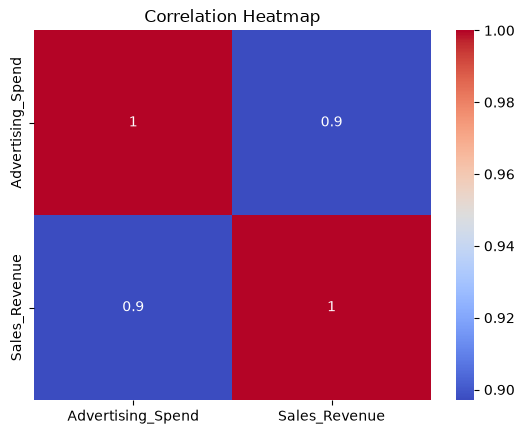

In [26]:

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


## Step 5: Scatter Plot with Regression Line

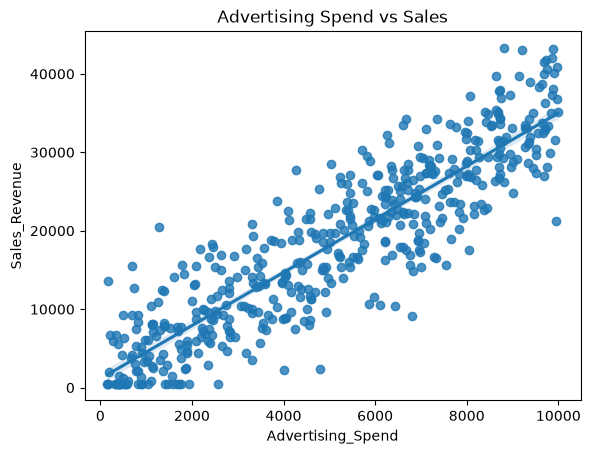

In [27]:

sns.regplot(x='Advertising_Spend', y='Sales_Revenue', data=df)
plt.title("Advertising Spend vs Sales")
plt.show()


## Step 6: Train-Test Split

In [28]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Step 7: Train Model

In [29]:

model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[3.42]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Advertising_Spend']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1014
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


## Step 8: Prediction

In [30]:

y_pred = model.predict(X_test)
print("Actual:", y_test.values)
print("Predicted:", y_pred)


Actual: [ 8831.54478681 14919.39862899  9758.58308426 21913.99672993
 43043.91899314  4678.04800243 31251.20127812 27069.23276565
   500.         27284.77658052 26456.83437606  2181.58903776
 27420.92685166 35042.72734388 13559.87182809 20168.10970036
 33443.62081476 27747.77544156  2182.73947821 26411.80749265
 33092.73547889 11237.77501649 42000.17660532 16662.30719444
 30414.87042834 26888.48861788 22926.34109404 36927.03571667
 31178.58271226 32409.79181869 16513.87569551 27785.55602251
 38124.02736114 34210.651652   28648.51617259 18947.22587653
 31993.55223439 17551.69563125 16676.13387348 15815.75887672
 17565.57286486 25305.26566757  7945.52388186 13359.87930405
  8145.71063136   500.         10562.77514382 15667.17859591
 24805.90282451 25842.99699802   500.          5968.10585869
  2731.66559991  9669.40345576 20870.99407865 12311.11890478
 30296.32604196 16557.25071502 43206.87663962 12599.17861486
 31626.30654112 29462.93153153 21323.74293479 22627.06672235
 35005.31166082 

## Step 9: Evaluation Metrics

In [31]:

print("MAE:", mean_absolute_error(y_test,y_pred))
print("MSE:", mean_squared_error(y_test,y_pred))
print("R2:", r2_score(y_test,y_pred))


MAE: 4573.577538723408
MSE: 30888754.70109166
R2: 0.7592517676013648


In [32]:

r2 = r2_score(y_test, y_pred)
accuracy = r2 * 100
print("Accuracy (%):", accuracy)


Accuracy (%): 75.92517676013648
